In [73]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [74]:
!pip install -U scikit-posthocs

In [75]:
import sys
sys.path.append('/content/drive/MyDrive/Colab Notebooks/Forecast')

import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import utils.plot_dashes as plot_dashes
import scikit_posthocs as sp

from scipy.stats import friedmanchisquare
from conf.processing import DataProcessing
from utils import genetic_algorithm as gen_alg
from models import ann_models, kernel_method, tree_based_ensemble as tree_based

pd.set_option('display.float_format', '{:.6f}'.format)

Dataset

In [76]:
all_results = []
all_runs = []
ga_runs = []

def get_file():

    file_path = '/content/drive/MyDrive/Colab Notebooks/Forecast/Datasets'

    for f in os.listdir(file_path):
        full_path = os.path.join(file_path, f)

        yield full_path

for f in get_file():

    dataset = pd.read_csv(f, sep='\t', decimal='.')
    raw_data = DataProcessing(dataset, n_lags=5)
    prep_data = raw_data.prepare_data()

    mlp = ann_models.MLP()
    results_MLP = mlp.train(prep_data)
    MLP_forecast_v = np.array(results_MLP['pred_valid'])
    MLP_forecast = np.array(results_MLP['pred_test_denom'])
    
    scn = ann_models.GridSCN()
    results_SCN = scn.train(prep_data)
    SCN_forecast_v = np.array(results_SCN['pred_valid'])
    SCN_forecast = np.array(results_SCN['pred_test'])

    elm = ann_models.GridELM()
    results_ELM = elm.train(prep_data)
    ELM_forecast_v = np.array(results_ELM['pred_valid'])
    ELM_forecast = np.array(results_ELM['pred_test_denom'])

    svr = kernel_method.SVM()
    results_SVR = svr.train(prep_data)
    SVR_forecast_v = np.array(results_SVR['pred_valid'])
    SVR_forecast = np.array(results_SVR['pred_test'])
    
    rf = tree_based.RF()
    results_RF = rf.train(prep_data)
    RF_forecast_v = np.array(results_RF['pred_valid'])
    RF_forecast = np.array(results_RF['pred_test'])

    gb = tree_based.GBoosting()
    results_GB = gb.train(prep_data)
    GB_forecast_v = np.array(results_GB['pred_valid'])
    GB_forecast = np.array(results_GB['pred_test'])

    P_v = np.column_stack(
        (
            MLP_forecast_v.copy(), 
            SCN_forecast_v.copy(),
            ELM_forecast_v.copy(), 
            SVR_forecast_v.copy(), 
            RF_forecast_v.copy(), 
            GB_forecast_v.copy()
        )
    )

    P = np.column_stack(
        (
            MLP_forecast.copy(), 
            SCN_forecast.copy(),
            ELM_forecast.copy(), 
            SVR_forecast.copy(), 
            RF_forecast.copy(), 
            GB_forecast.copy()
        )
    )
    
    for x in range(30):
        
        ga = gen_alg.GeneticAlgorithm()
        
        ga_result = ga.execute(P_v, prep_data['target_valid'])

        y_hat = P @ ga_result['best_ind']
        ga_metrics = plot_dashes.get_metrics_error(prep_data['target_test'], y_hat)

        ga_runs.append({

            'Dataset': os.path.basename(f),
            'Run': x,

            'MSE': ga_metrics['MSE'],
            'RMSE': ga_metrics['RMSE'],
            'MAE': ga_metrics['MAE'],
            'MAPE': ga_metrics['MAPE'],

            'Weights': ga_result['best_ind'],
            'Fitness': ga_result['best_fitness'],
            'Fitness_Curve': ga_result['fitness_curve']

        })

    ga_dataset = [ run for run in ga_runs if run["Dataset"] == os.path.basename(f) ]

    best = max( 
        ga_dataset,
        key=lambda r: r["Fitness"]
    )

    y_hat_final = P @ best["Weights"]

    weights = np.array([1/6]*6)
    ensemble_mean = P @ weights

    MLP = plot_dashes.get_metrics_error(prep_data['target_test'], MLP_forecast)
    SCN = plot_dashes.get_metrics_error(prep_data['target_test'], SCN_forecast)
    ELM = plot_dashes.get_metrics_error(prep_data['target_test'], ELM_forecast)
    SVR = plot_dashes.get_metrics_error(prep_data['target_test'], SVR_forecast)
    RF = plot_dashes.get_metrics_error(prep_data['target_test'], RF_forecast)
    GB = plot_dashes.get_metrics_error(prep_data['target_test'], GB_forecast)
    EMEAN = plot_dashes.get_metrics_error(prep_data['target_test'], ensemble_mean)
    GA = plot_dashes.get_metrics_error(prep_data['target_test'], y_hat_final)

    all_results.append({
        'dataset': os.path.basename(f),
        'MLP': MLP,
        'SCN': SCN,
        'ELM': ELM,
        'SVR': SVR,
        'RF': RF,
        'GB': GB,
        'EMEAN': EMEAN,
        'GA': GA
    })

    all_runs.append({
        'dataset': os.path.basename(f),
        'model': 'MLP',
        'runs': results_MLP['lst_results']
    })

    all_runs.append({
        'dataset': os.path.basename(f),
        'model': 'SCN',
        'runs': results_SCN['lst_results']
    })

    all_runs.append({
        'dataset': os.path.basename(f),
        'model': 'ELM',
        'runs': results_ELM['lst_results']
    })

    all_runs.append({
        'dataset': os.path.basename(f),
        'model': 'SVR',
        'runs': results_SVR['lst_results']
    })

    all_runs.append({
        'dataset': os.path.basename(f),
        'model': 'RF',
        'runs': results_RF['lst_results']
    })

    all_runs.append({
        'dataset': os.path.basename(f),
        'model': 'GB',
        'runs': results_GB['lst_results']
    })
    

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro

In [77]:
df_results = pd.DataFrame(all_results)
df_runs = pd.DataFrame(all_runs)

In [78]:
# 1. Tabela Principal (MSE, RMSE, MAE e MAPE)
rows = []

for _, row in df_results.iterrows():

    dataset = row['dataset']

    for model in ['MLP','SCN','ELM','SVR','RF','GB', 'EMEAN', 'GA']:
        metrics = row[model]
        rows.append({

            'Dataset': dataset,
            'Model': model,

            'MSE': metrics['MSE'],
            'RMSE': metrics['RMSE'],
            'MAE': metrics['MAE'],
            'MAPE': metrics['MAPE']

        })

df_metrics = pd.DataFrame(rows)

In [79]:
df_metrics

,Dataset,Model,MSE,RMSE,MAE,MAPE
0,airlines.txt,MLP,3677.685524,60.643924,46.947457,0.099546
1,airlines.txt,SCN,6732.190972,82.049930,63.733921,0.147922
2,airlines.txt,ELM,13056.578224,114.265385,91.632377,0.206911
3,airlines.txt,SVR,15222.424587,123.379190,105.387674,0.222434
4,airlines.txt,RF,22154.295907,148.843192,127.779707,0.269653
5,airlines.txt,GB,20154.553053,141.966732,120.217282,0.252672
6,airlines.txt,EMEAN,7458.418485,86.362136,70.223400,0.146514
7,airlines.txt,GA,2170.288716,46.586358,39.322533,0.089043
8,coloradoRiver.txt,MLP,0.297891,0.545794,0.407296,1.312045
9,coloradoRiver.txt,SCN,0.425690,0.652449,0.461851,0.794178


In [80]:
# 2. Média das Métricas por Modelo
df_metrics.groupby('Model')[['MSE','RMSE','MAE','MAPE']].mean()

,MSE,RMSE,MAE,MAPE
Model,,,,
ELM,138096.401368,212.857089,173.731097,0.531620
EMEAN,147007.067934,212.769765,164.513955,0.420582
GA,131287.782074,193.132198,155.980430,0.426627
GB,213095.889385,264.281201,216.764766,0.676636
MLP,139184.519131,201.782364,152.773564,0.592510
RF,163754.746141,236.826305,182.850561,0.433501
SCN,139134.873820,206.612450,163.466892,0.577341
SVR,407780.949493,349.343362,264.713658,0.451048


In [81]:
# 3. Ranking dos Modelos
ranking = []

for dataset in df_metrics['Dataset'].unique():

    temp = df_metrics[df_metrics['Dataset']==dataset]
    temp = temp.sort_values('MSE')
    temp['Rank'] = range(1,len(temp)+1)
    ranking.append(temp)

df_rank = pd.concat(ranking)

In [82]:
df_rank

,Dataset,Model,MSE,RMSE,MAE,MAPE,Rank
7,airlines.txt,GA,2170.288716,46.586358,39.322533,0.089043,1
0,airlines.txt,MLP,3677.685524,60.643924,46.947457,0.099546,2
1,airlines.txt,SCN,6732.190972,82.049930,63.733921,0.147922,3
6,airlines.txt,EMEAN,7458.418485,86.362136,70.223400,0.146514,4
2,airlines.txt,ELM,13056.578224,114.265385,91.632377,0.206911,5
3,airlines.txt,SVR,15222.424587,123.379190,105.387674,0.222434,6
5,airlines.txt,GB,20154.553053,141.966732,120.217282,0.252672,7
4,airlines.txt,RF,22154.295907,148.843192,127.779707,0.269653,8
10,coloradoRiver.txt,ELM,0.267761,0.517457,0.265164,0.360666,1
15,coloradoRiver.txt,GA,0.279877,0.529034,0.326388,0.496878,2


In [83]:
df_rank.groupby('Model')['Rank'].mean()

,Rank
Model,
ELM,3.250000
EMEAN,3.250000
GA,1.500000
GB,7.000000
MLP,4.250000
RF,6.250000
SCN,4.750000
SVR,5.750000


In [84]:
# 4. Média e Desvio das Execuções - Valores NaN

rows=[]

for _,row in df_runs.iterrows():

    for i,mse in enumerate(row['runs']):

        rows.append({

            'Dataset':row['dataset'],
            'Model':row['model'],
            'Run':i,
            'MSE':mse

        })

df_runs_expand = pd.DataFrame(rows)

df_runs_expand.groupby(
    ['Dataset','Model']
)['MSE'].agg(
    ['mean','std','min','max']
)

mean           std            min  \
Dataset           Model                                               
airlines.txt      ELM     15093.553818   2095.041896   12297.708970   
                  GB      20172.847557     38.575053   20154.553053   
                  MLP      4045.443629   1093.692864    3677.685524   
                  RF      22549.442353    540.641534   22154.295907   
                  SCN      6732.190972           NaN    6732.190972   
                  SVR     15222.424587           NaN   15222.424587   
coloradoRiver.txt ELM         0.263830      0.005171       0.256461   
                  GB          0.374943      0.000000       0.374943   
                  MLP         0.318504      0.029437       0.277628   
                  RF          0.482189      0.013456       0.477933   
                  SCN         0.425690           NaN       0.425690   
                  SVR         0.315603           NaN       0.315603   
lynx.txt          ELM    706179.757974 284306.399572  539323.656732   
                  GB     832734.800840   1078.090296  832223.417711   
                  MLP    557553.219704  28530.463384  507075.470156   
                  RF     683606.410090  50378.316588  632859.165130   
                  SCN    549801.765439           NaN  549801.765439   
                  SVR   1615895.979524           NaN 1615895.979524   
melbmin.txt       ELM         5.122249      0.034327       5.102754   
                  GB          5.212669      0.001766       5.211832   
                  MLP         5.100387      0.022292       5.079239   
                  RF          5.045595      0.000000       5.045595   
                  SCN         5.113181           NaN       5.113181   
                  SVR         5.078260           NaN       5.078260   

                                   max  
Dataset           Model                 
airlines.txt      ELM     16704.493965  
                  GB      20247.567894  
                  MLP      7152.880000  
                  RF      23652.130469  
                  SCN      6732.190972  
                  SVR     15222.424587  
coloradoRiver.txt ELM         0.267761  
                  GB          0.374943  
                  MLP         0.351731  
                  RF          0.520486  
                  SCN         0.425690  
                  SVR         0.315603  
lynx.txt          ELM   1503331.327036  
                  GB     834780.333355  
                  MLP    587937.584708  
                  RF     740547.933896  
                  SCN    549801.765439  
                  SVR   1615895.979524  
melbmin.txt       ELM         5.186507  
                  GB          5.216019  
                  MLP         5.121536  
                  RF          5.045595  
                  SCN         5.113181  
                  SVR         5.078260

In [85]:
# 5. Organizar o GA

df_ga = pd.DataFrame(ga_runs)

In [86]:
df_ga.groupby('Dataset')['MSE'].mean()

,MSE
Dataset,
airlines.txt,2390.785151
coloradoRiver.txt,0.280375
lynx.txt,526861.925540
melbmin.txt,5.022617


In [87]:
df_ga.groupby('Dataset')['MSE'].std()

,MSE
Dataset,
airlines.txt,419.049239
coloradoRiver.txt,0.006693
lynx.txt,9187.562203
melbmin.txt,0.007691


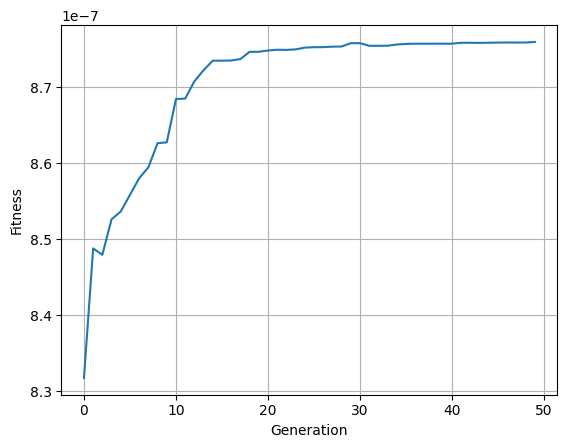

In [88]:
# 7. Curva de Convergência

ga_result['fitness_curve']
plt.plot(ga_result['fitness_curve'])
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.grid()
plt.show()

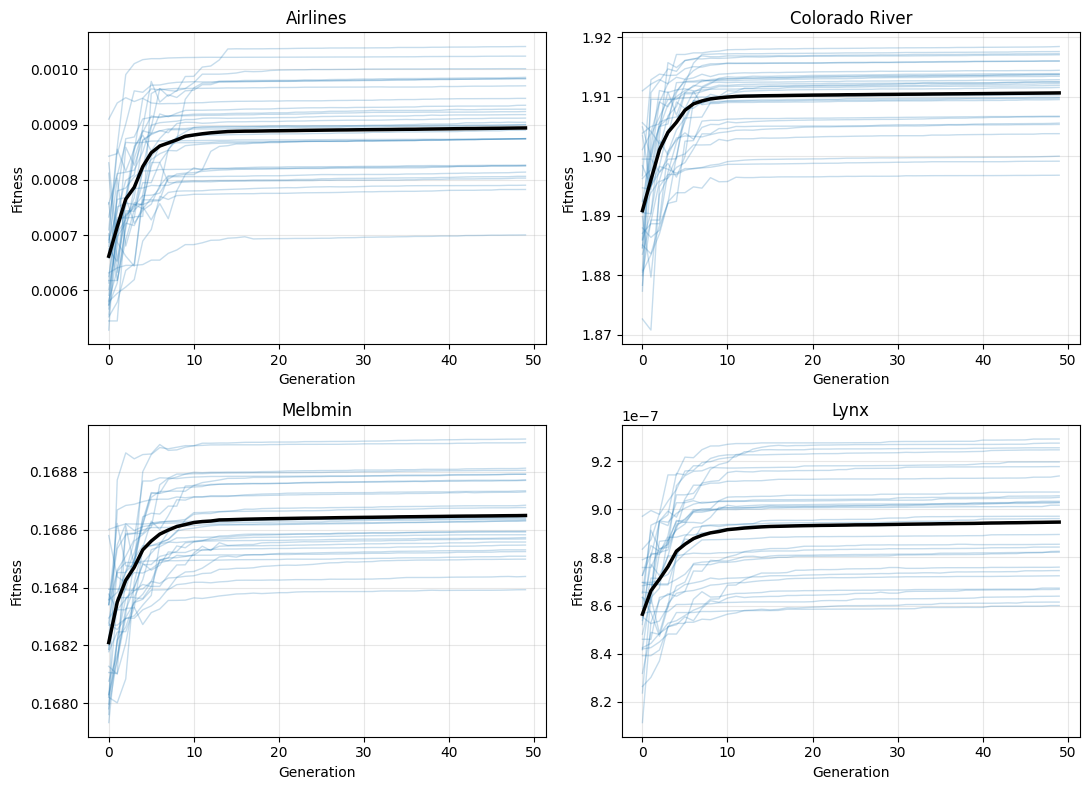

In [89]:
datasets = [
    "airlines.txt",
    "coloradoRiver.txt",
    "melbmin.txt",
    "lynx.txt"
]

titles = [
    "Airlines",
    "Colorado River",
    "Melbmin",
    "Lynx"
]

fig, axes = plt.subplots(2, 2, figsize=(11,8))

axes = axes.flatten()

for ax, dataset, title in zip(axes, datasets, titles):

    fitness_curves = np.array([
        run["Fitness_Curve"]
        for run in ga_runs
        if run["Dataset"] == dataset
    ])

    mean_curve = fitness_curves.mean(axis=0)

    # Todas as execuções
    for curve in fitness_curves:
        ax.plot(
            curve,
            color='tab:blue',
            alpha=0.25,
            linewidth=1
        )

    # Média
    ax.plot(
        mean_curve,
        color='black',
        linewidth=2.5,
        label='Average'
    )

    ax.set_title(title)
    ax.set_xlabel("Generation")
    ax.set_ylabel("Fitness")
    ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "ga_convergence.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

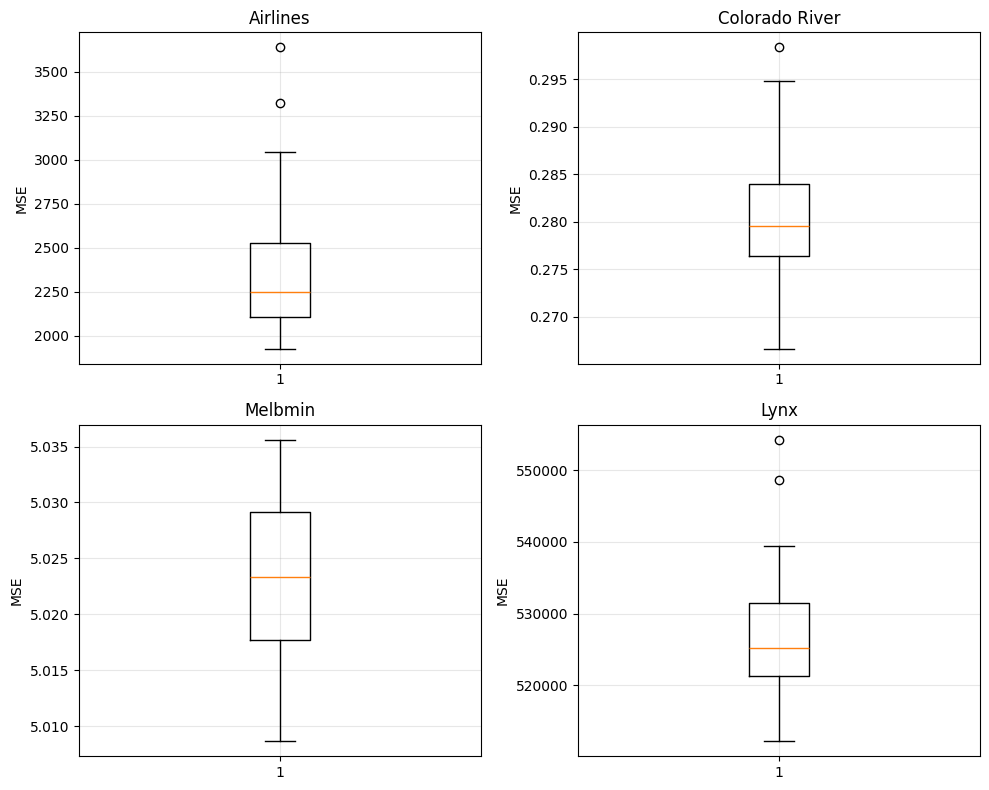

In [90]:
datasets = [
    "airlines.txt",
    "coloradoRiver.txt",
    "melbmin.txt",
    "lynx.txt"
]

titles = [
    "Airlines",
    "Colorado River",
    "Melbmin",
    "Lynx"
]

fig, axes = plt.subplots(2, 2, figsize=(10,8))

axes = axes.flatten()

for ax, dataset, title in zip(axes, datasets, titles):

    dados = df_ga[df_ga["Dataset"] == dataset]["MSE"]

    ax.boxplot(dados)

    ax.set_title(title)

    ax.set_ylabel("MSE")

    ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "ga_boxplots.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [96]:
# Friedman

friedman_df = df_metrics.pivot(
    index='Dataset',
    columns='Model',
    values='MSE'

)

In [97]:
friedman_df

Model,ELM,EMEAN,GA,GB,MLP,RF,SCN,SVR
Dataset,,,,,,,,
airlines.txt,13056.578224,7458.418485,2170.288716,20154.553053,3677.685524,22154.295907,6732.190972,15222.424587
coloradoRiver.txt,0.267761,0.280146,0.279877,0.374943,0.297891,0.477933,0.425690,0.315603
lynx.txt,539323.656732,580564.556547,522975.528966,832223.417711,553054.971571,632859.165130,549801.765439,1615895.979524
melbmin.txt,5.102754,5.016556,5.030737,5.211832,5.121536,5.045595,5.113181,5.078260


In [98]:
friedmanchisquare(

friedman_df['MLP'],
friedman_df['SCN'],
friedman_df['ELM'],
friedman_df['SVR'],
friedman_df['RF'],
friedman_df['GB'],
friedman_df['EMEAN'],
friedman_df['GA']
)

FriedmanchisquareResult(statistic=np.float64(15.416666666666657), pvalue=np.float64(0.03101419068097797))

In [99]:
nemenyi = sp.posthoc_nemenyi_friedman(
    friedman_df.values
)
nemenyi.index = friedman_df.columns
nemenyi.columns = friedman_df.columns

In [100]:
nemenyi

Model,ELM,EMEAN,GA,GB,MLP,RF,SCN,SVR
Model,,,,,,,,
ELM,1.000000,1.000000,0.973060,0.373136,0.999135,0.666146,0.988970,0.837013
EMEAN,1.000000,1.000000,0.973060,0.373136,0.999135,0.666146,0.988970,0.837013
GA,0.973060,0.973060,1.000000,0.032289,0.757943,0.110081,0.567270,0.215662
GB,0.373136,0.373136,0.032289,1.000000,0.757943,0.999872,0.899562,0.996387
MLP,0.999135,0.999135,0.757943,0.757943,1.000000,0.944413,0.999992,0.988970
RF,0.666146,0.666146,0.110081,0.999872,0.944413,1.000000,0.988970,0.999992
SCN,0.988970,0.988970,0.567270,0.899562,0.999992,0.988970,1.000000,0.999135
SVR,0.837013,0.837013,0.215662,0.996387,0.988970,0.999992,0.999135,1.000000


In [101]:
ranks = friedman_df.rank(axis=1, ascending=True)
avg_ranks = ranks.mean(axis=0)
avg_ranks

,0
Model,
ELM,3.250000
EMEAN,3.250000
GA,1.500000
GB,7.000000
MLP,4.250000
RF,6.250000
SCN,4.750000
SVR,5.750000


{'markers': [<matplotlib.collections.PathCollection at 0x7c33f05457c0>,
 'elbows': [<matplotlib.lines.Line2D at 0x7c33f085b410>,
 'labels': [Text(1.49, -3, 'GA (1.5)'),
  Text(1.49, -4, 'ELM (3.2)'),
  Text(1.49, -5, 'EMEAN (3.2)'),
  Text(1.49, -6, 'MLP (4.2)'),
  Text(7.01, -3, '(7) GB'),
  Text(7.01, -4, '(6.2) RF'),
  Text(7.01, -5, '(5.8) SVR'),
  Text(7.01, -6, '(4.8) SCN')],
 'crossbars': [[<matplotlib.lines.Line2D at 0x7c33f2c74170>],
  [<matplotlib.lines.Line2D at 0x7c33f085ae40>]]}

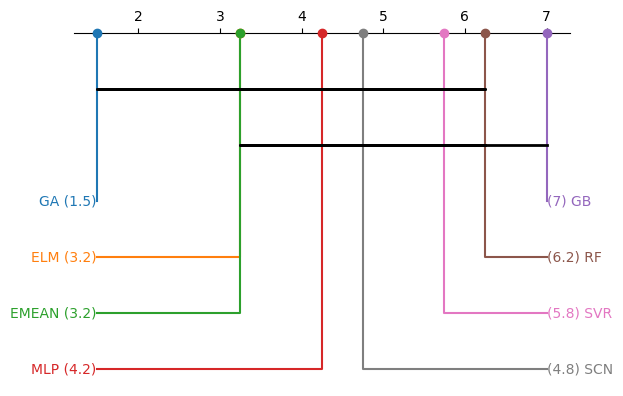

In [102]:
from scikit_posthocs import critical_difference_diagram

critical_difference_diagram(
    avg_ranks,
    nemenyi
)

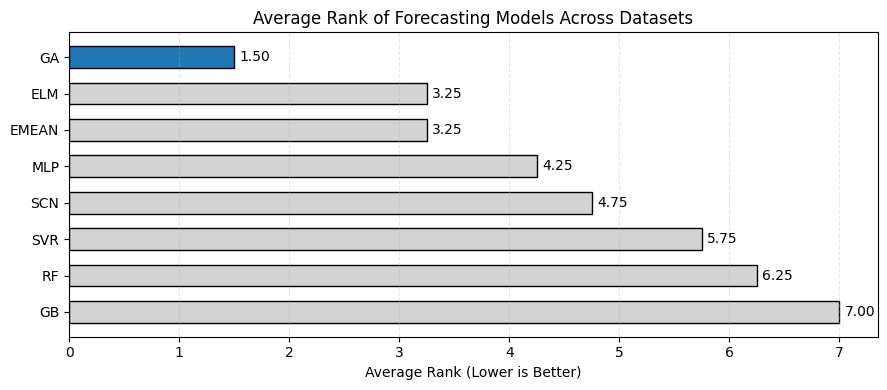

In [103]:
avg_rank = (
    df_rank
    .groupby('Model')['Rank']
    .mean()
    .sort_values()
)

# Todos com Cinza
colors = ['lightgray'] * len(avg_rank)

# GA destaque
ga_idx = avg_rank.index.get_loc('GA')
colors[ga_idx] = 'tab:blue'

fig, ax = plt.subplots(figsize=(9,4))

bars = ax.barh(
    avg_rank.index,
    avg_rank.values,
    color=colors,
    edgecolor='black',
    height=0.6
)

ax.invert_yaxis()

ax.set_xlabel("Average Rank (Lower is Better)")
ax.set_title("Average Rank of Forecasting Models Across Datasets")

ax.grid(axis='x', linestyle='--', alpha=0.3)

for bar in bars:
    ax.text(
        bar.get_width()+0.05,
        bar.get_y()+bar.get_height()/2,
        f"{bar.get_width():.2f}",
        va='center'
    )

plt.tight_layout()
plt.show()